In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


import string
!pip install emoji
import emoji
from bs4 import BeautifulSoup


import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer


from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)


from sklearn.model_selection import train_test_split


from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [5]:
txt_df=pd.read_csv('/content/archive (1).zip')

In [6]:
txt_df.head(5)

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [7]:
new_df = txt_df.sample(
    20000,
    random_state=42
)

In [8]:
new_df.head(5)

,product_name,product_price,Rate,Review,Summary,Sentiment
193551,BAJAJ 17 L Solo Microwave Oven1701MT White,4498,1,worst experience ever!,not working properly,neutral
149083,ScotchBrite Sponge WipeLarge Pack of 3,189,5,just wow!,very good,positive
194975,limraz furniture Engineered Wood Computer Desk...,1298,5,classy product,it is perfect if you want to work on the compu...,positive
29981,Lakm?? Eyeconic Kajal Twin Pack??????(Deep Bla...,218,5,simply awesome,thanks flipkart,positive
137259,KENT Aura Portable Room Air PurifierPink,6999,5,simply awesome,thanks product looks good not sure if any inst...,positive


In [9]:
new_df.isnull()

,product_name,product_price,Rate,Review,Summary,Sentiment
193551,False,False,False,False,False,False
149083,False,False,False,False,False,False
194975,False,False,False,False,False,False
29981,False,False,False,False,False,False
137259,False,False,False,False,False,False
...,...,...,...,...,...,...
46036,False,False,False,True,False,False
18106,False,False,False,False,False,False
2848,False,False,False,False,False,False
16886,False,False,False,False,False,False


In [10]:
new_df.isnull().sum()

,0
product_name,0
product_price,0
Rate,0
Review,2389
Summary,0
Sentiment,0


In [11]:
# Fill null values in the 'Review' column with an empty string
new_df['Review'] = new_df['Review'].fillna('')

# Verify that there are no more null values in the 'Review' column
print("Null values after filling:")
print(new_df.isnull().sum())


Null values after filling:
product_name     0
product_price    0
Rate             0
Review           0
Summary          0
Sentiment        0
dtype: int64


/tmp/ipykernel_2764/3582119790.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df['Review'].fillna('', inplace=True)


In [12]:
new_df.duplicated()

,0
193551,False
149083,False
194975,False
29981,False
137259,False
...,...
46036,False
18106,False
2848,False
16886,False


In [13]:
num_duplicates = new_df.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 891


In [14]:
new_df.drop_duplicates(inplace=True)
print(f"DataFrame shape after dropping duplicates: {new_df.shape}")

DataFrame shape after dropping duplicates: (19109, 6)


In [15]:
# Identify object (string) columns
str_col = new_df.select_dtypes(include='object').columns

# Convert each string column to lowercase
for col in str_col:
    new_df[col] = new_df[col].str.lower()

print("DataFrame converted to lowercase for string columns:")
display(new_df.head())

DataFrame converted to lowercase for string columns:


,product_name,product_price,Rate,Review,Summary,Sentiment
193551,bajaj 17 l solo microwave oven1701mt white,4498,1,worst experience ever!,not working properly,neutral
149083,scotchbrite sponge wipelarge pack of 3,189,5,just wow!,very good,positive
194975,limraz furniture engineered wood computer desk...,1298,5,classy product,it is perfect if you want to work on the compu...,positive
29981,lakm?? eyeconic kajal twin pack??????(deep bla...,218,5,simply awesome,thanks flipkart,positive
137259,kent aura portable room air purifierpink,6999,5,simply awesome,thanks product looks good not sure if any inst...,positive


In [16]:
import re

def remove_html_tags(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', str(text)) # Convert to string to handle potential non-string types

# Ensure all string columns have nulls filled with empty strings before applying HTML tag removal
for col in str_col:
    new_df[col] = new_df[col].fillna('') # Fill NaN values with empty strings
    new_df[col] = new_df[col].apply(remove_html_tags)

print("DataFrame after removing HTML tags from string columns:")
display(new_df.head(2))


DataFrame after removing HTML tags from string columns:


,product_name,product_price,Rate,Review,Summary,Sentiment
193551,bajaj 17 l solo microwave oven1701mt white,4498,1,worst experience ever!,not working properly,neutral
149083,scotchbrite sponge wipelarge pack of 3,189,5,just wow!,very good,positive


In [17]:
def remove_emojis(text):
    return emoji.replace_emoji(text, replace='')

# Apply the function to all string columns
for col in str_col:
    new_df[col] = new_df[col].apply(remove_emojis)

print("DataFrame after removing emojis from string columns:")
display(new_df.head(2))


DataFrame after removing emojis from string columns:


,product_name,product_price,Rate,Review,Summary,Sentiment
193551,bajaj 17 l solo microwave oven1701mt white,4498,1,worst experience ever!,not working properly,neutral
149083,scotchbrite sponge wipelarge pack of 3,189,5,just wow!,very good,positive


In [18]:
import re

def remove_mojibake_chars(text):
    # This regex targets the specific pattern '?ðòðò' and similar non-standard characters
    # The '?' character needs to be escaped in regex
    # It also handles the trailing parenthesis if present.
    pattern = r'[?ðòðò]+(?:\(...)?'
    return re.sub(pattern, '', text)

# Apply the function to all string columns
for col in str_col:
    new_df[col] = new_df[col].apply(remove_mojibake_chars)

print("DataFrame after removing mojibake characters from string columns:")
display(new_df.head(2))


DataFrame after removing mojibake characters from string columns:


,product_name,product_price,Rate,Review,Summary,Sentiment
193551,bajaj 17 l solo microwave oven1701mt white,4498,1,worst experience ever!,not working properly,neutral
149083,scotchbrite sponge wipelarge pack of 3,189,5,just wow!,very good,positive


In [19]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply the function to all string columns
for col in str_col:
    new_df[col] = new_df[col].apply(remove_punctuation)

print("DataFrame after removing punctuation from string columns:")
display(new_df.head(2))


DataFrame after removing punctuation from string columns:


,product_name,product_price,Rate,Review,Summary,Sentiment
193551,bajaj 17 l solo microwave oven1701mt white,4498,1,worst experience ever,not working properly,neutral
149083,scotchbrite sponge wipelarge pack of 3,189,5,just wow,very good,positive


In [20]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Apply the function to all string columns
for col in str_col:
    new_df[col] = new_df[col].apply(remove_numbers)

print("DataFrame after removing numbers from string columns:")
display(new_df.head(2))


DataFrame after removing numbers from string columns:


,product_name,product_price,Rate,Review,Summary,Sentiment
193551,bajaj l solo microwave ovenmt white,,,worst experience ever,not working properly,neutral
149083,scotchbrite sponge wipelarge pack of,,,just wow,very good,positive


In [21]:
import re

def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

# Apply the function to all string columns
for col in str_col:
    new_df[col] = new_df[col].apply(remove_extra_spaces)

print("DataFrame after removing extra spaces from string columns:")
display(new_df.head(2))


DataFrame after removing extra spaces from string columns:


,product_name,product_price,Rate,Review,Summary,Sentiment
193551,bajaj l solo microwave ovenmt white,,,worst experience ever,not working properly,neutral
149083,scotchbrite sponge wipelarge pack of,,,just wow,very good,positive


In [22]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get English stop words
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split() # Split text into words
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Apply the function to all string columns
for col in str_col:
    new_df[col] = new_df[col].apply(remove_stopwords)

print("DataFrame after removing stop words from string columns:")
display(new_df.head(2))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


DataFrame after removing stop words from string columns:


,product_name,product_price,Rate,Review,Summary,Sentiment
193551,bajaj l solo microwave ovenmt white,,,worst experience ever,working properly,neutral
149083,scotchbrite sponge wipelarge pack,,,wow,good,positive


In [23]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [24]:
nltk.download('punkt_tab')

def tokenize_text(text):
    return word_tokenize(text)

# Apply tokenization to 'Review' and 'Summary' columns
new_df['Review_tokens'] = new_df['Review'].apply(tokenize_text)
new_df['Summary_tokens'] = new_df['Summary'].apply(tokenize_text)

print("DataFrame after tokenizing 'Review' and 'Summary' columns:")
display(new_df[['Review', 'Review_tokens', 'Summary', 'Summary_tokens']].head(2))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


DataFrame after tokenizing 'Review' and 'Summary' columns:


,Review,Review_tokens,Summary,Summary_tokens
193551,worst experience ever,"[worst, experience, ever]",working properly,"[working, properly]"
149083,wow,[wow],good,[good]


In [25]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [26]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

# Apply lemmatization to the tokenized columns
new_df['Review_lemmas'] = new_df['Review_tokens'].apply(lemmatize_tokens)
new_df['Summary_lemmas'] = new_df['Summary_tokens'].apply(lemmatize_tokens)

print("DataFrame after lemmatizing 'Review_tokens' and 'Summary_tokens' columns:")
display(new_df[['Review_tokens', 'Review_lemmas', 'Summary_tokens', 'Summary_lemmas']].head(2))

DataFrame after lemmatizing 'Review_tokens' and 'Summary_tokens' columns:


,Review_tokens,Review_lemmas,Summary_tokens,Summary_lemmas
193551,"[worst, experience, ever]","[worst, experience, ever]","[working, properly]","[working, properly]"
149083,[wow],[wow],[good],[good]


In [27]:
# Convert lists of lemmas back into strings for TF-IDF vectorization
new_df['Review_text_lemmatized'] = new_df['Review_lemmas'].apply(lambda x: ' '.join(x))
new_df['Summary_text_lemmatized'] = new_df['Summary_lemmas'].apply(lambda x: ' '.join(x))

print("Converted lemmatized token lists back to strings:")
display(new_df[['Review_text_lemmatized', 'Summary_text_lemmatized']].head(2))

Converted lemmatized token lists back to strings:


,Review_text_lemmatized,Summary_text_lemmatized
193551,worst experience ever,working properly
149083,wow,good


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for demonstration

# Fit and transform the 'Review_text_lemmatized' column
X_reviews = tfidf_vectorizer.fit_transform(new_df['Review_text_lemmatized'])
print(f"TF-IDF features for Reviews shape: {X_reviews.shape}")

# Transforming the 'Summary_text_lemmatized' column using the same fitted vectorizer
X_summaries = tfidf_vectorizer.transform(new_df['Summary_text_lemmatized'])
print(f"TF-IDF features for Summaries shape: {X_summaries.shape}")

TF-IDF features for Reviews shape: (19109, 263)
TF-IDF features for Summaries shape: (19109, 263)


In [29]:
# Define features (X) and target (y)
X = X_reviews # Using TF-IDF features from 'Review' column
y = new_df['Sentiment']

# Perform train-test split
# Using a common split ratio of 80% training and 20% testing
# stratify=y ensures that the proportion of target variable values is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (15287, 263)
Shape of X_test: (3822, 263)
Shape of y_train: (15287,)
Shape of y_test: (3822,)


## Model Training and Evaluation

We will now train and evaluate two common classification models for text data: Logistic Regression and Multinomial Naive Bayes. We will use the `X_train` and `y_train` sets for training and `X_test` and `y_test` for evaluation.

### Logistic Regression

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.66      0.75       540
     neutral       0.00      0.00      0.00       202
    positive       0.89      0.99      0.94      3080

    accuracy                           0.89      3822
   macro avg       0.58      0.55      0.56      3822
weighted avg       0.84      0.89      0.86      3822



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


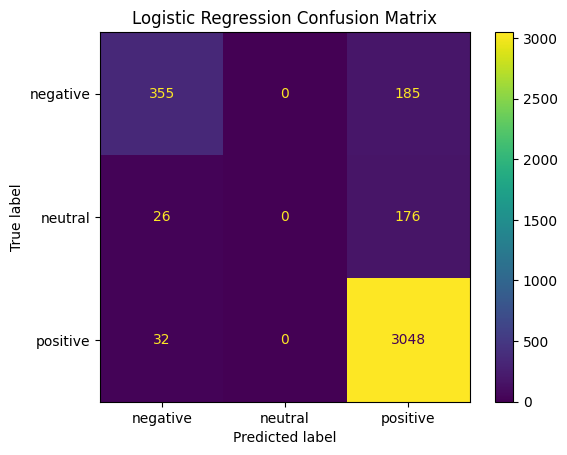

In [30]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the Logistic Regression model
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

# Display confusion matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg, labels=log_reg_model.classes_)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=log_reg_model.classes_)
disp_log_reg.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()

### Multinomial Naive Bayes

In [ ]:
# Initialize and train the Multinomial Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# Evaluate the Multinomial Naive Bayes model
print("Multinomial Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Display confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot()
plt.title('Multinomial Naive Bayes Confusion Matrix')
plt.show()


## Improving Neutral Sentiment Detection

Both Logistic Regression and Multinomial Naive Bayes models struggled significantly with the 'neutral' sentiment class, classifying none of them correctly. This often indicates a class imbalance or that the current features are not distinctive enough for this particular class.

First, let's visualize the sentiment distribution in our dataset to confirm if class imbalance is an issue.

/tmp/ipykernel_2764/1007209729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=new_df, palette='viridis')


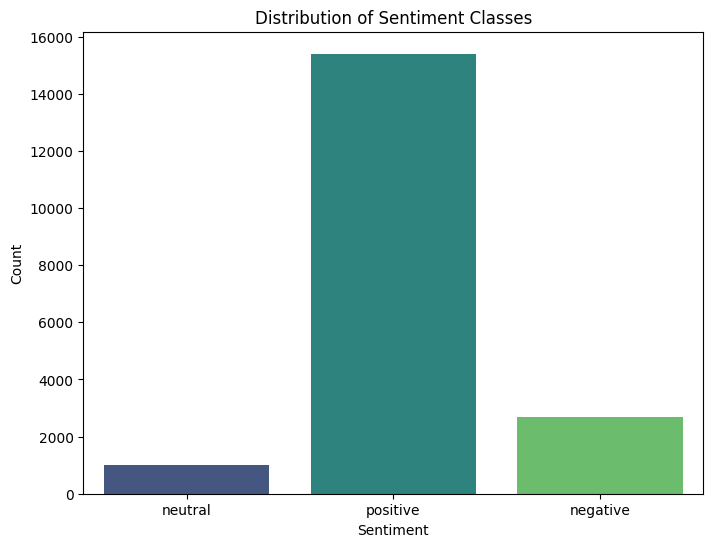

Sentiment class distribution:
Sentiment
positive    15401
negative     2697
neutral      1011
Name: count, dtype: int64


In [31]:
# Visualize the distribution of sentiment classes
plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=new_df, hue='Sentiment', palette='viridis', legend=False)
plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Print the exact counts
print("Sentiment class distribution:")
print(new_df['Sentiment'].value_counts())

In [32]:
# Re-initialize TF-IDF Vectorizer with N-grams
# We'll use (1, 2) n-grams (unigrams and bigrams)
# max_features can be adjusted if needed, but let's keep it to ensure a manageable feature set initially
tfidf_vectorizer_ngram = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit and transform the 'Review_text_lemmatized' column with N-grams
X_reviews_ngram = tfidf_vectorizer_ngram.fit_transform(new_df['Review_text_lemmatized'])
print(f"TF-IDF features for Reviews (N-grams) shape: {X_reviews_ngram.shape}")

# Redefine features (X) and target (y) with N-gram features
X_ngram = X_reviews_ngram
y_ngram = new_df['Sentiment']

# Perform train-test split again with N-gram features
X_train_ngram, X_test_ngram, y_train_ngram, y_test_ngram = train_test_split(X_ngram, y_ngram, test_size=0.2, random_state=42, stratify=y_ngram)

print(f"Shape of X_train (N-grams): {X_train_ngram.shape}")
print(f"Shape of X_test (N-grams): {X_test_ngram.shape}")
print(f"Shape of y_train (N-grams): {y_train_ngram.shape}")
print(f"Shape of y_test (N-grams): {y_test_ngram.shape}")

TF-IDF features for Reviews (N-grams) shape: (19109, 552)
Shape of X_train (N-grams): (15287, 552)
Shape of X_test (N-grams): (3822, 552)
Shape of y_train (N-grams): (15287,)
Shape of y_test (N-grams): (3822,)


Now that we have N-gram features, let's retrain the Logistic Regression model and see if the performance on the 'neutral' class improves.

Logistic Regression (N-grams + Balanced Class Weights) Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.66      0.74       540
     neutral       0.12      0.57      0.20       202
    positive       0.96      0.77      0.85      3080

    accuracy                           0.74      3822
   macro avg       0.65      0.67      0.60      3822
weighted avg       0.90      0.74      0.80      3822



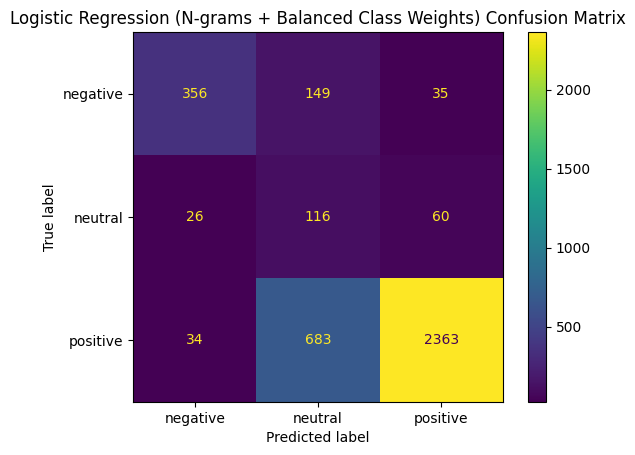

In [33]:
# Initialize and train the Logistic Regression model with N-gram features and balanced class weights
log_reg_model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg_model_balanced.fit(X_train_ngram, y_train_ngram)

# Make predictions on the test set
y_pred_log_reg_balanced = log_reg_model_balanced.predict(X_test_ngram)

# Evaluate the Logistic Regression model with balanced class weights
print("Logistic Regression (N-grams + Balanced Class Weights) Classification Report:")
print(classification_report(y_test_ngram, y_pred_log_reg_balanced))

# Display confusion matrix
cm_log_reg_balanced = confusion_matrix(y_test_ngram, y_pred_log_reg_balanced, labels=log_reg_model_balanced.classes_)
disp_log_reg_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg_balanced, display_labels=log_reg_model_balanced.classes_)
disp_log_reg_balanced.plot()
plt.title('Logistic Regression (N-grams + Balanced Class Weights) Confusion Matrix')
plt.show()

## Predictions

Now, let's see some of the predictions made by our Logistic Regression model (with N-grams and balanced class weights) on the test set, alongside the actual sentiments.

In [34]:
# Create a DataFrame to display actual vs. predicted sentiments for a sample
predictions_df = pd.DataFrame({
    'Actual_Sentiment': y_test_ngram,
    'Predicted_Sentiment': y_pred_log_reg_balanced
})

# Display the first few predictions
print("Sample of Actual vs. Predicted_Sentiments:")
display(predictions_df.sample(10, random_state=42))

Sample of Actual vs. Predicted_Sentiments:


,Actual_Sentiment,Predicted_Sentiment
188183,negative,negative
25857,neutral,positive
79354,positive,positive
28551,positive,positive
162335,positive,positive
179306,positive,positive
27937,positive,positive
148927,positive,positive
126107,negative,negative
17996,positive,positive


In [35]:
def predict_review(review_text):
    # Apply preprocessing steps
    processed_review = review_text.lower()
    processed_review = remove_html_tags(processed_review)
    processed_review = remove_emojis(processed_review)
    processed_review = remove_mojibake_chars(processed_review)
    processed_review = remove_punctuation(processed_review)
    processed_review = remove_numbers(processed_review)
    processed_review = remove_extra_spaces(processed_review)
    processed_review = remove_stopwords(processed_review)
    tokens = tokenize_text(processed_review)
    lemmas = lemmatize_tokens(tokens)
    lemmatized_text = ' '.join(lemmas)

    # Vectorize the preprocessed review
    # Ensure to use the fitted n-gram TF-IDF vectorizer
    review_vectorized = tfidf_vectorizer_ngram.transform([lemmatized_text])

    # Make prediction using the balanced Logistic Regression model
    prediction = log_reg_model_balanced.predict(review_vectorized)
    return prediction[0]

# Example usage:
review = "I absolutely loved this phone."
predicted_sentiment = predict_review(review)
print(f"Review: '{review}'")
print(f"Predicted Sentiment: {predicted_sentiment}")

Review: 'I absolutely loved this phone.'
Predicted Sentiment: neutral


In [36]:
def preprocess_text(text):
    processed_text = text.lower()
    processed_text = remove_html_tags(processed_text)
    processed_text = remove_emojis(processed_text)
    processed_text = remove_mojibake_chars(processed_text)
    processed_text = remove_punctuation(processed_text)
    processed_text = remove_numbers(processed_text)
    processed_text = remove_extra_spaces(processed_text)
    processed_text = remove_stopwords(processed_text)
    tokens = tokenize_text(processed_text)
    lemmas = lemmatize_tokens(tokens)
    return ' '.join(lemmas)

review = "I absolutely loved this phone."

processed = preprocess_text(review)
print(processed)

vector = tfidf_vectorizer_ngram.transform([processed])

print("Classes:", log_reg_model_balanced.classes_)
print("Probabilities:", log_reg_model_balanced.predict_proba(vector)[0])

absolutely loved phone
Classes: ['negative' 'neutral' 'positive']
Probabilities: [0.34079873 0.37027796 0.28892331]


In [37]:
for review in ["Worst product ever.", "Excellent product.", "Average product."]:
    print(f"Review: '{review}' -> Predicted Sentiment: {predict_review(review)}")


'positive'

In [38]:
for review in ["Amazing product", "Excellent phone", "Very bad product", "Worst phone ever"]:
    print(f"Review: '{review}' -> Predicted Sentiment: {predict_review(review)}")


'negative'